In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve,auc
from sklearn.utils.class_weight import compute_class_weight

In [2]:
covid_df=pd.read_csv("Covid Dataset.csv")

In [3]:
covid_df.sample(10)

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
5344,Yes,No,Yes,Yes,No,Yes,No,No,Yes,Yes,...,No,No,No,Yes,Yes,Yes,No,No,No,Yes
183,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,...,Yes,Yes,Yes,No,Yes,No,No,No,No,Yes
2861,Yes,No,Yes,Yes,No,No,Yes,No,Yes,Yes,...,No,No,No,Yes,Yes,No,Yes,No,No,Yes
4615,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,...,No,No,No,No,No,Yes,No,No,No,No
942,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,...,Yes,No,Yes,Yes,No,Yes,Yes,No,No,Yes
3298,Yes,Yes,Yes,No,Yes,No,Yes,Yes,Yes,No,...,No,No,No,Yes,Yes,No,Yes,No,No,Yes
3469,Yes,Yes,Yes,No,No,Yes,Yes,No,No,Yes,...,Yes,No,Yes,Yes,No,Yes,Yes,No,No,Yes
3566,No,Yes,Yes,No,No,No,Yes,No,No,No,...,Yes,Yes,Yes,No,No,No,Yes,No,No,Yes
782,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,...,No,Yes,No,Yes,Yes,No,No,No,No,Yes
4191,No,No,No,No,Yes,No,No,No,No,Yes,...,Yes,No,No,No,No,Yes,No,No,No,No


In [4]:
X=covid_df.drop('COVID-19',axis=1)
y=covid_df['COVID-19']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [5]:
oneHot = OneHotEncoder()

X_train = oneHot.fit_transform(X_train)
X_test = oneHot.transform(X_test)

labelEncoder = LabelEncoder()
y_train = labelEncoder.fit_transform(y_train)
y_test = labelEncoder.transform(y_test)

In [6]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight= 'balanced',classes=  classes,y= y_train)
class_weights = dict(zip(classes, weights))

In [14]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

d:\.conda\envs\AItwo\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,553 (13.88 KB)

 Trainable params: 3,553 (13.88 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(X_train, y_train, epochs=100,validation_split=0.2, batch_size=32, class_weight=class_weights)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8898 - loss: 0.3509 - val_accuracy: 0.9414 - val_loss: 0.1724
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9482 - loss: 0.1375 - val_accuracy: 0.9667 - val_loss: 0.0987
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9525 - loss: 0.1087 - val_accuracy: 0.9460 - val_loss: 0.1259
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9612 - loss: 0.0854 - val_accuracy: 0.9621 - val_loss: 0.0743
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9632 - loss: 0.0752 - val_accuracy: 0.9517 - val_loss: 0.0969
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9687 - loss: 0.0644 - val_accuracy: 0.9586 - val_loss: 0.0741
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9684 - loss: 0.0595 - val_accuracy: 0.9793 - val_loss: 0.0574
Epoch 8/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9733 - loss: 0.0555 - val_accu

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9807 - loss: 0.0446
Loss: 0.0446
Accuracy: 0.9807


In [17]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
print(classification_report(y_test, y_pred))

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       210
           1       1.00      0.98      0.99       877

    accuracy                           0.98      1087
   macro avg       0.95      0.99      0.97      1087
weighted avg       0.98      0.98      0.98      1087



In [18]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[210   0]
 [ 21 856]]


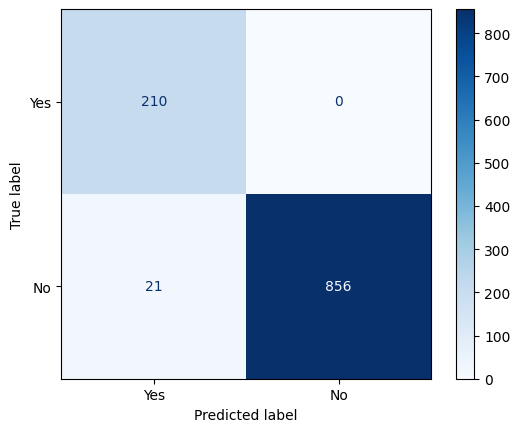

In [19]:
ConfusionMatrixDisplay(confusion_matrix=cm,display_labels= covid_df['COVID-19'].unique()).plot(cmap=plt.cm.Blues)
plt.show()

Area under the curve:  0.9880273660205245


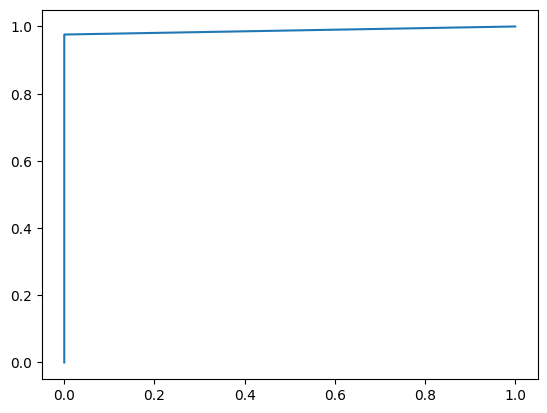

In [20]:
fpr,tpr , threasholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr,tpr)  

print("Area under the curve: ",roc_auc)
plt.plot(fpr,tpr)
plt.show()